### Nicole Kapellmann Lepine A01664563

## Cálculo de datos iniciales 

In [17]:
import pandas as pd
import numpy as np

In [18]:
## Lectura de datos
csv_file_name = "datos.csv"
df= pd.DataFrame()
df = pd.read_csv(csv_file_name)
print("Tamaño del DataFrame:")
print(df.shape)

Tamaño del DataFrame:
(30, 1)


In [19]:
## Obtener el rango 
max_val = df["valor"].max()
min_val = df["valor"].min()

print("Máximo:", max_val)
print("Mínimo:", min_val)

rango = max_val - min_val
print("El rango es:", rango)

Máximo: 0.995
Mínimo: 0.018
El rango es: 0.977


In [20]:
## Obtener k 
N = len(df)
k = 1 + 3.322 * np.log10(N)
k = round(k, 1)
print("k :",k)

k : 5.9


In [21]:
## Obtener 
clase = rango / k 
clase = round(clase, 1)
print("clase :",clase)


clase : 0.2


In [22]:
## Para sacar lambda 
from numpy import mean
valor_esperado = mean(df)
print("E(X)", valor_esperado)

var_lambda = round(1 / valor_esperado)
print("Lambda", var_lambda)

E(X) 0.5461666666666666
Lambda 2


In [23]:
## Obtener la frecuencia absoluta
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

labels = [
    "0.0 - 0.2",
    "0.2 - 0.4",
    "0.4 - 0.6",
    "0.6 - 0.8",
    "0.8 - 1.0"
]

df["Clase"] = pd.cut(df["valor"], bins=bins, labels=labels, include_lowest=True)

tabla = df["Clase"].value_counts().sort_index()
tabla = tabla.reset_index()
tabla.columns = ["Clase", "Frecuencia"]

print(tabla)



       Clase  Frecuencia
0  0.0 - 0.2           4
1  0.2 - 0.4           5
2  0.4 - 0.6           8
3  0.6 - 0.8           7
4  0.8 - 1.0           6


## Generar tabla para Prueba Chi-Cuadrada

### a) Exponencial negativa

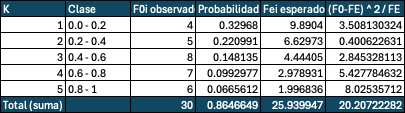

Función para sacar probabilidad con WolframAplha: 
<p align="center"><strong>Integrate[λ*Exp[-λ*x], {x, límite inferior, límite superior}]<strong></p>

Grados de libertad: (k - 1) - num. parámetros = 4 - 1 = 3 

Consultando el valor en la tabla con nivel de significania alfa de 5% y 3 grados de libertad = **7.81**

<p align="center">20.21 > 7.81</p>, por lo tanto Ηo se rechaza; no se puede decir que es una distribución exponencial negativa. 

### b) Uniforme

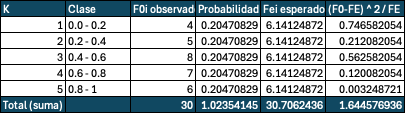

Función para sacar probabilidad en excel: 
$$
f(x) = \frac{x2 - x1}{b - a}
$$

Grados de libertad: (k - 1) - num. parámetros = 4 

Consultando el valor en la tabla con nivel de significania alfa de 5% y 4 grados de libertad = **9.49**

<p align="center">1.64 < 9.49</p>, por lo tanto Ηo no se rechaza, por lo tanto se puede decir que tienen una distribución uniforme. 